In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import VotingClassifier

sns.set_style("whitegrid")

In [30]:
df = pd.read_csv(r"d:\Mini Project\Project phishing\Phishing-Detection-Based-on-URL-\phishing.csv")
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [5]:
df.shape

(11054, 32)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [7]:
df['class'] = df['class'].replace(-1,0)

In [8]:
df['class'].value_counts()

class
1    6157
0    4897
Name: count, dtype: int64

In [9]:
df = df.drop("Index", axis=1)

In [10]:
df.isnull().sum()

UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

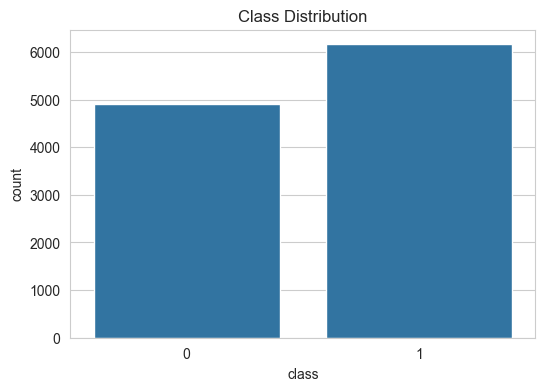

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['class'])
plt.title("Class Distribution")
plt.show()

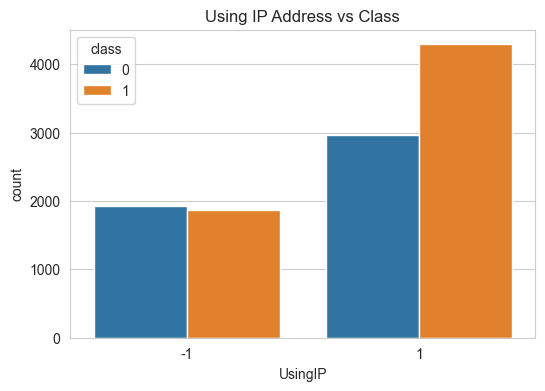

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="UsingIP", hue="class", data=df)
plt.title("Using IP Address vs Class")
plt.show()

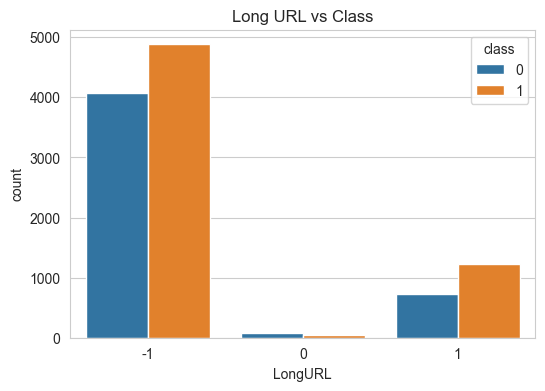

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="LongURL", hue="class", data=df)
plt.title("Long URL vs Class")
plt.show()

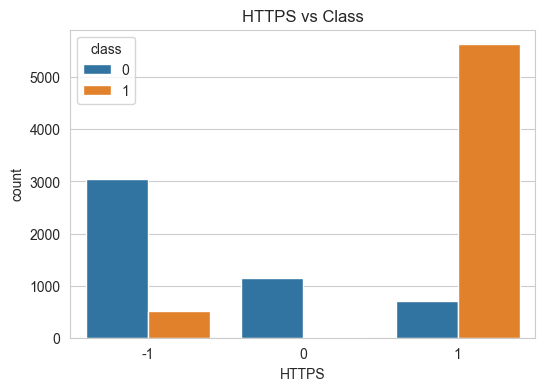

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="HTTPS", hue="class", data=df)
plt.title("HTTPS vs Class")
plt.show()

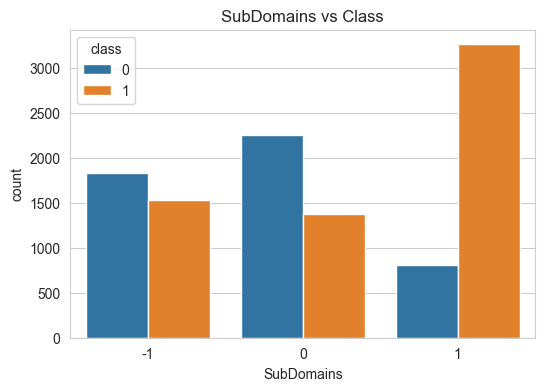

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="SubDomains", hue="class", data=df)
plt.title("SubDomains vs Class")
plt.show()

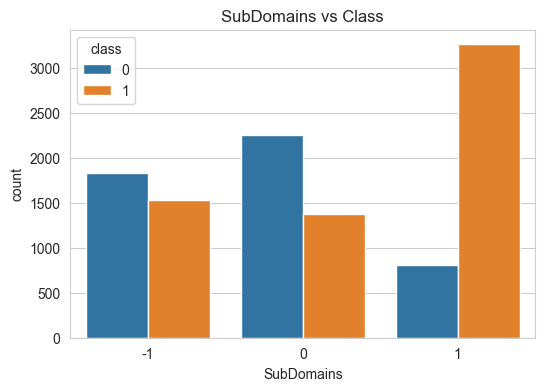

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="SubDomains", hue="class", data=df)
plt.title("SubDomains vs Class")
plt.show()

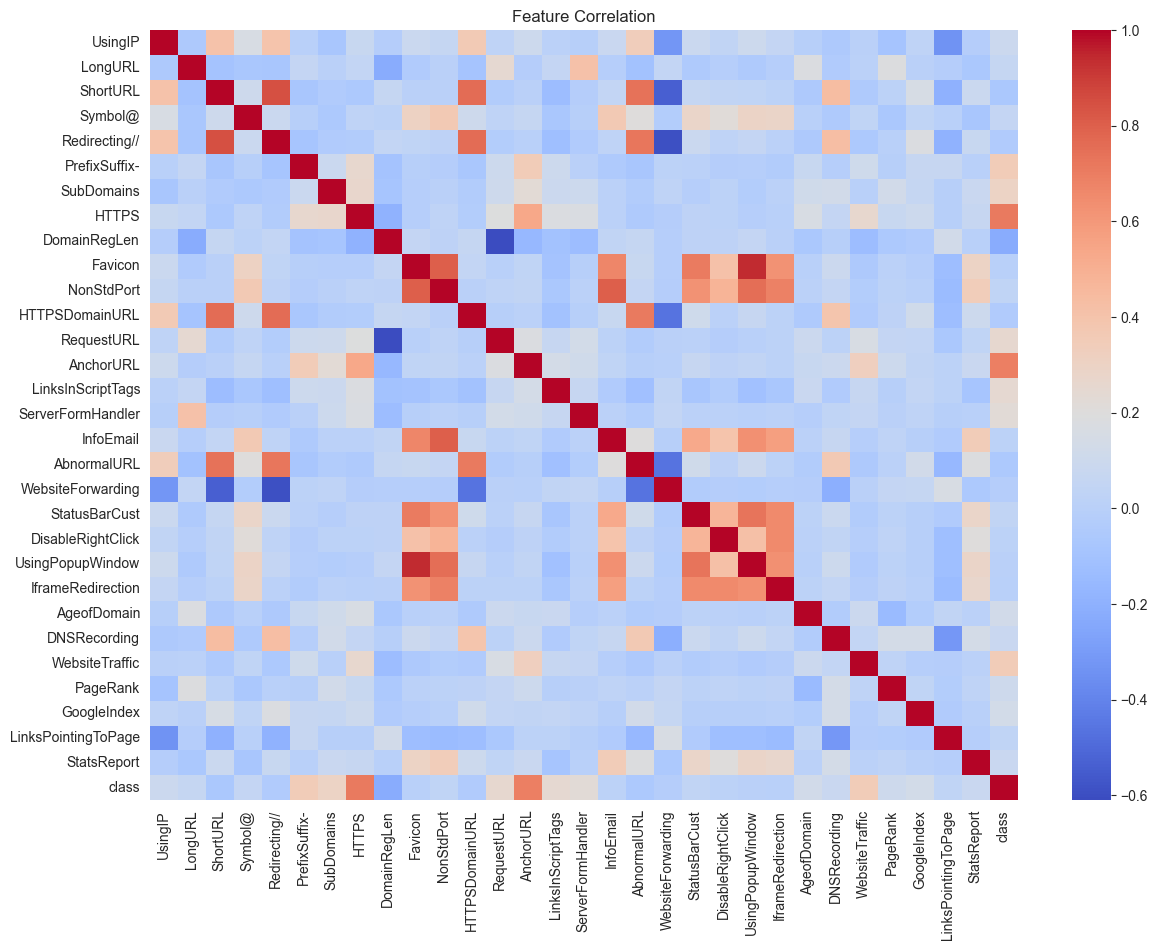

In [17]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [18]:
X = df.drop("class", axis=1)
y = df["class"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [20]:
models = {

"Decision Tree": DecisionTreeClassifier(),

"Naive Bayes": GaussianNB(),

"Random Forest": RandomForestClassifier(n_estimators=100),

"SVM": SVC(),

"Gradient Boosting": GradientBoostingClassifier(),

"Linear Regression": LinearRegression()

}

In [21]:
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

print("All models trained successfully")

All models trained successfully


In [22]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    if name == "Linear Regression":
        y_pred = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=[
"Model",
"Accuracy",
"Precision",
"Recall",
"F1 Score"
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.962315,0.964190,0.968851,0.966515
1,Naive Bayes,0.605668,0.996416,0.298604,0.459504
2,Random Forest,0.966838,0.964475,0.976907,0.970651
3,SVM,0.946639,0.936755,0.970462,0.953310
4,Gradient Boosting,0.948749,0.945732,0.964017,0.954787
5,Linear Regression,0.922219,0.917708,0.946294,0.931782


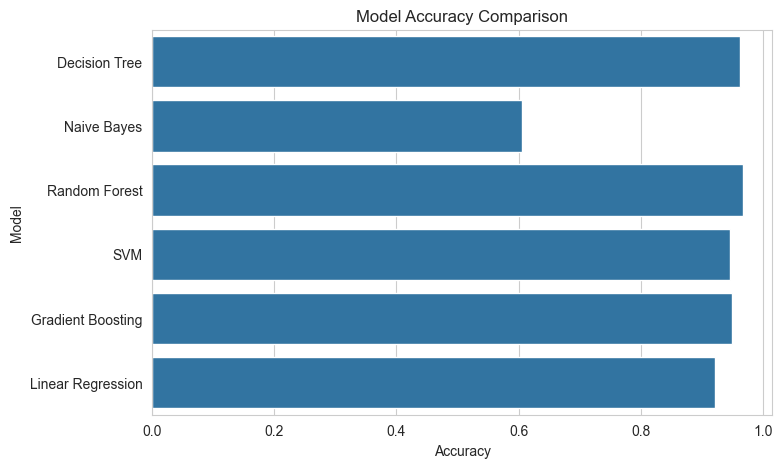

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
x="Accuracy",
y="Model",
data=results_df
)

plt.title("Model Accuracy Comparison")
plt.show()

In [24]:
lr = LogisticRegression(max_iter=5000)
svm = SVC()
dt = DecisionTreeClassifier()

hard_voting = VotingClassifier(
estimators=[
('lr', lr),
('svm', svm),
('dt', dt)
],
voting='hard'
)

hard_voting.fit(X_train, y_train)

,estimators,"[('lr', ...), ('svm', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [25]:
lr = LogisticRegression(max_iter=5000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

soft_voting = VotingClassifier(
estimators=[
('lr', lr),
('svm', svm),
('dt', dt)
],
voting='soft'
)

soft_voting.fit(X_train, y_train)

,estimators,"[('lr', ...), ('svm', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [26]:
for name, model in {

"Hard Voting": hard_voting,
"Soft Voting": soft_voting

}.items():

    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

Hard Voting
Accuracy: 0.9472414832680133
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1455
           1       0.94      0.97      0.95      1862

    accuracy                           0.95      3317
   macro avg       0.95      0.94      0.95      3317
weighted avg       0.95      0.95      0.95      3317

Soft Voting
Accuracy: 0.9580946638528791
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1455
           1       0.95      0.97      0.96      1862

    accuracy                           0.96      3317
   macro avg       0.96      0.96      0.96      3317
weighted avg       0.96      0.96      0.96      3317



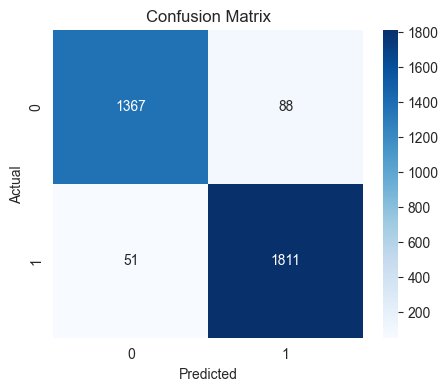

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
rf = RandomForestClassifier()

rf.fit(X, y)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({

"Feature": X.columns,
"Importance": importance

}).sort_values(by="Importance", ascending=False)

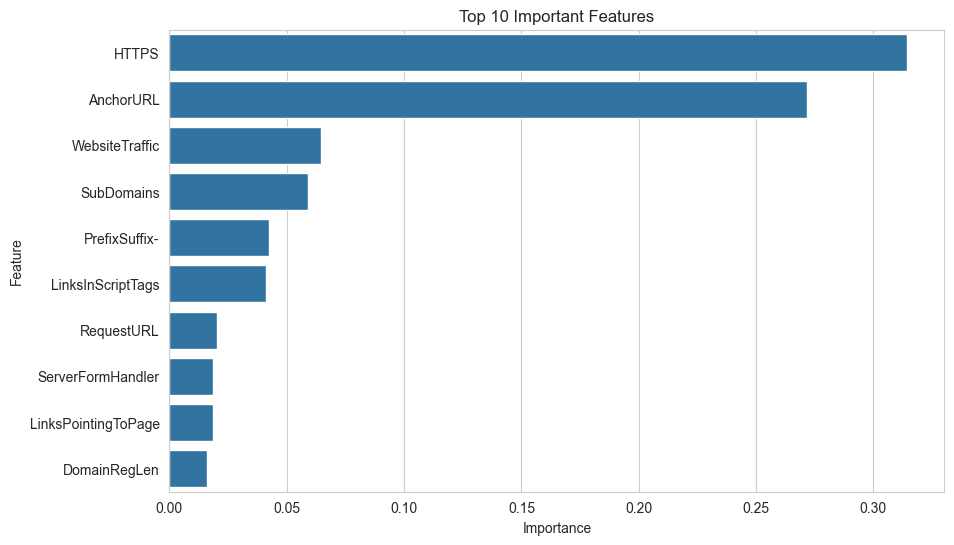

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
x="Importance",
y="Feature",
data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()